# Getting started: exploring TM-QSAR-Benchmark results

This is a short, beginner-friendly tour of the benchmark's **melted /
long-format** result CSVs -- one row per (dataset, split, fold, descriptor,
model, score type) combination. If you want a deeper statistical analysis
(Tukey HSD post-hoc tests, effect sizes, clause/epoch sweeps), see
`post-hoc-analysis.ipynb` instead; this notebook only covers the basics of
loading and visually comparing TM vs Random Forest vs XGBoost.

Run a benchmark first if you don't already have result files, e.g.:

```bash
pixi run benchmark-8
```

which writes `results/MACRO_TM_Benchmark_8` (and a per-fold
`MICRO_TM_Benchmark_8`). This notebook uses the small, already-committed
`results/MACRO_TM_Benchmark_ALL_NClauses` file so it works out of the box
without running a benchmark first -- swap in your own file below.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

RESULTS_PATH = "../results/MACRO_TM_Benchmark_ALL_NClauses"
# To use output from a benchmark you just ran instead, e.g.:
# RESULTS_PATH = "../results/MACRO_TM_Benchmark_8"

df = pd.read_csv(RESULTS_PATH)
# Some committed result files carry leftover pandas index columns from
# concatenating multiple runs (e.g. "Unnamed: 0") -- safe to drop.
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.head()

,TargetDataset,Group,Split,Fold,Descriptor,HPSearchTime,TrainTime,InferenceTime,TotalTime,Params,Epochs,Model,Dataset,Score,ScoreType,ClauseFactor,N_Clauses
0,opioids/MOR_cutoff6.csv,random,0,0,ECFP,146.776141,0.12768,0.093663,146.997485,"{'T': 379, 's': 4.174980299183584, 'number_of_...",1,TsetlinMachine,Train,0.880381,ROC_AUC,1,100
1,opioids/MOR_cutoff6.csv,random,0,0,ECFP,146.776141,0.12768,0.093663,146.997485,"{'T': 379, 's': 4.174980299183584, 'number_of_...",1,TsetlinMachine,Train,0.782267,PRC_AUC,1,100
2,opioids/MOR_cutoff6.csv,random,0,0,ECFP,146.776141,0.12768,0.093663,146.997485,"{'T': 379, 's': 4.174980299183584, 'number_of_...",1,TsetlinMachine,Train,0.603627,PPV,1,100
3,opioids/MOR_cutoff6.csv,random,0,0,ECFP,146.776141,0.12768,0.093663,146.997485,"{'T': 379, 's': 4.174980299183584, 'number_of_...",1,TsetlinMachine,Train,0.910671,NPV,1,100
4,opioids/MOR_cutoff6.csv,random,0,0,ECFP,146.776141,0.12768,0.093663,146.997485,"{'T': 379, 's': 4.174980299183584, 'number_of_...",1,TsetlinMachine,Test,0.882860,ROC_AUC,1,100


## Understanding the "melted" format

Each row is a single (dataset, split, fold, descriptor, model, score type)
observation, rather than one row per run with separate columns per metric.
This is intentional -- it makes it trivial to filter/group/plot with pandas
and seaborn without reshaping. The key columns:

| Column | Meaning |
|---|---|
| `TargetDataset` | Which dataset CSV under `data/` this row is from (e.g. MOR, DOR, KOR) |
| `Group` | Cross-validation split strategy: `random`, `butina`, or `scaffold` |
| `Split` / `Fold` | Outer CV split index / inner CV fold index |
| `Descriptor` | Molecular descriptor used: `ECFP` or `RDKit2D` |
| `Model` | `TsetlinMachine`, `RandomForest`, or `XGBoost` |
| `Dataset` | `Train` or `Test` -- which partition the score was computed on |
| `Score` / `ScoreType` | The metric value and its name (`ROC_AUC`, `PRC_AUC`, `PPV`, `NPV`) |
| `Params` | The hyperparameters used for that model/fold |

Let's see what values are actually present:

In [2]:
for col in ["Model", "ScoreType", "Dataset", "Group", "Descriptor"]:
    print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")

Model: ['RandomForest', 'TsetlinMachine', 'XGBoost']
ScoreType: ['NPV', 'PPV', 'PRC_AUC', 'ROC_AUC']
Dataset: ['Test', 'Train']
Group: ['butina', 'random', 'scaffold']
Descriptor: ['ECFP', 'RDKit2D']


## Comparing TM vs Random Forest vs XGBoost

Filter down to test-set ROC-AUC for a single target/descriptor/split
combination, then compare models directly.

In [3]:
target = "opioids/MOR_cutoff6.csv"

test_roc_auc = df[
    (df["TargetDataset"] == target)
    & (df["Dataset"] == "Test")
    & (df["ScoreType"] == "ROC_AUC")
    & (df["Descriptor"] == "ECFP")
]

test_roc_auc.groupby("Model")["Score"].agg(["mean", "std", "count"])

,mean,std,count
Model,,,
RandomForest,0.841750,0.085811,421
TsetlinMachine,0.860952,0.084857,21048
XGBoost,0.860618,0.093836,421


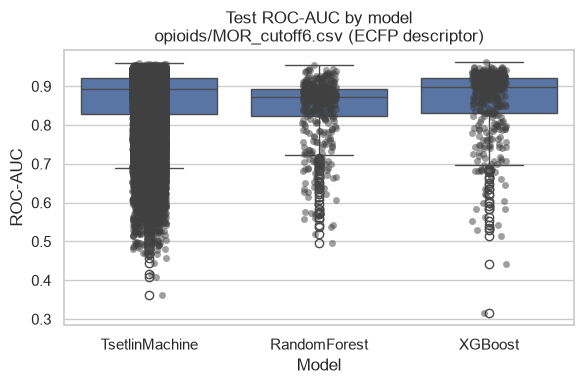

In [4]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=test_roc_auc, x="Model", y="Score")
sns.stripplot(data=test_roc_auc, x="Model", y="Score", color=".25", alpha=0.5)
plt.title(f"Test ROC-AUC by model\n{target} (ECFP descriptor)")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.show()

## Comparing multiple metrics at once

Melting is already done for us, so we can facet across `ScoreType` directly
with `seaborn.catplot`:

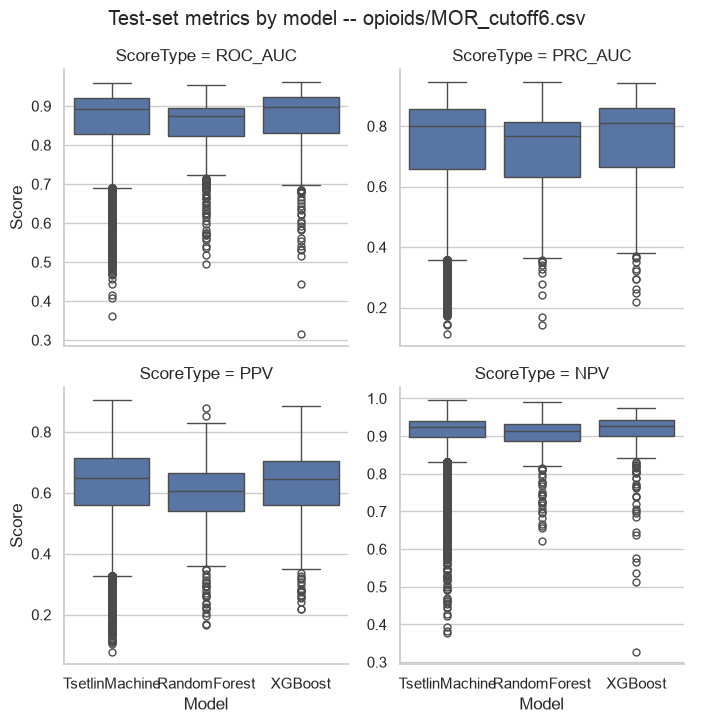

In [5]:
test_all_metrics = df[
    (df["TargetDataset"] == target)
    & (df["Dataset"] == "Test")
    & (df["Descriptor"] == "ECFP")
]

g = sns.catplot(
    data=test_all_metrics, x="Model", y="Score", col="ScoreType",
    kind="box", col_wrap=2, height=3.5, sharey=False,
)
g.figure.suptitle(f"Test-set metrics by model -- {target}", y=1.03)
plt.show()

## Comparing across targets

Finally, a quick look at how each model does across all targets in this
results file (test ROC-AUC, ECFP descriptor):

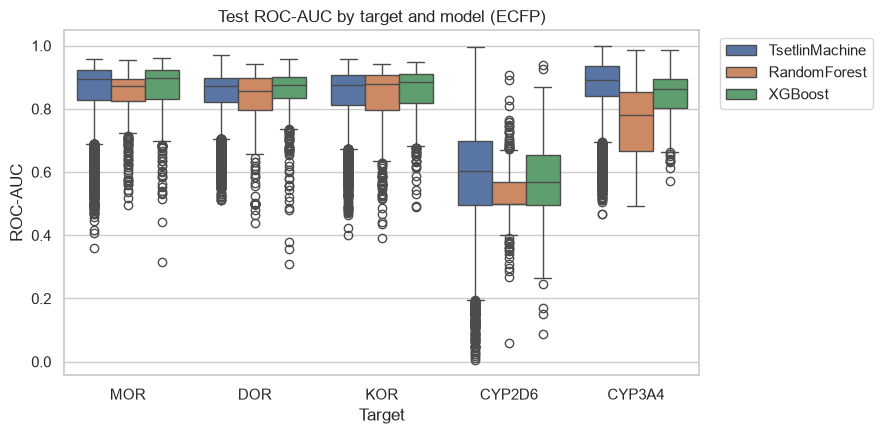

In [6]:
all_targets_roc_auc = df[
    (df["Dataset"] == "Test")
    & (df["ScoreType"] == "ROC_AUC")
    & (df["Descriptor"] == "ECFP")
].copy()
all_targets_roc_auc["Target"] = all_targets_roc_auc["TargetDataset"].str.split("/").str[-1].str.split("_").str[0]

plt.figure(figsize=(9, 4.5))
sns.boxplot(data=all_targets_roc_auc, x="Target", y="Score", hue="Model")
plt.title("Test ROC-AUC by target and model (ECFP)")
plt.ylabel("ROC-AUC")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Next steps

- Run your own benchmark (`pixi run benchmark-8` / `pixi run benchmark-16`,
  or the `tm_qsar_benchmark.cli` module directly) and point `RESULTS_PATH`
  at your new `results/MACRO_TM_Benchmark_*` file.
- For rigorous statistical comparison (Tukey HSD, effect sizes, per-epoch
  and per-clause sweeps), see `post-hoc-analysis.ipynb`.
- `src/tm_qsar_benchmark/analysis/model_comparison.py` has the plotting/stats
  helper functions used by that deeper-dive notebook, if you want to reuse
  them directly.